# Pseudotimes

We calculate pseudotimes and afterwards run the alignment of pseudotimes between cells and nuclei.
To do so we need cellalign. Instructions for installations just as future reference:

```
mamba install -c conda-forge r-dtw # in bash
install_github("shenorrLab/cellAlign", lib='environment/library/folder/for/R') # in R
```

In [1]:
%run ../Script/analysisLibraries

In [2]:
%run ../Script/pythonScripts.py

In [3]:
%matplotlib inline

In [4]:
%load_ext rpy2.ipython

In [5]:
adata = sc.read(f'./write/adata.norm.topo.1.h5ad')

Only considering the two last: ['.1', '.h5ad'].
Only considering the two last: ['.1', '.h5ad'].


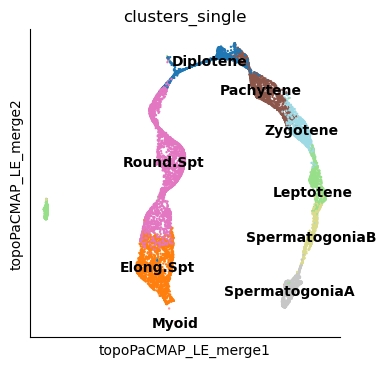

In [44]:
plt.rcParams["figure.figsize"] = (4, 4)
sc.pl.embedding(
    adata,
    basis="topoPaCMAP_LE_merge",
    color=['clusters_single'],
    palette="tab20",
    ncols=2,
    legend_loc="on data",
    legend_fontsize=10,
)

<Axes: ylabel='Count'>

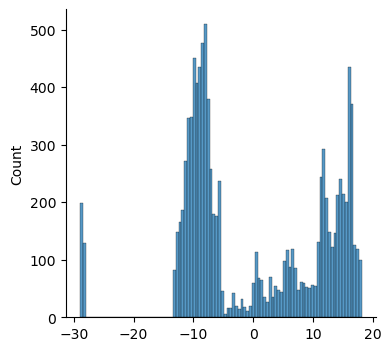

In [46]:
sns.histplot(adata.obsm['X_topoPaCMAP_LE_merge'][:,0], bins=100)

In [47]:
adata = adata[ adata.obsm['X_topoPaCMAP_LE_merge'][:,0] > -20].copy()

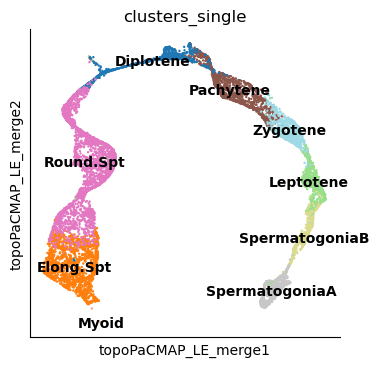

In [48]:
plt.rcParams["figure.figsize"] = (4, 4)
sc.pl.embedding(
    adata,
    basis="topoPaCMAP_LE_merge",
    color=['clusters_single'],
    palette="tab20",
    ncols=2,
    legend_loc="on data",
    legend_fontsize=10,
)

In [49]:
#NUCLEI = sc.read('./write/MERGED_normalized_04.h5ad')
#CELL = sc.read('../../wholecell_samuele/write/qc/DGE_03.h5ad')

In [50]:
NUCLEI = adata[adata.obs['batch']=='Nuclei'].copy()
CELLS = adata[adata.obs['batch']=='Cells'].copy()

## Pseudotime for cells

### Palantir

In [51]:
import palantir

In [52]:
CELLS.obsm['X_pca'] = CELLS.obsm['X_DM'][:,0:50].copy()

In [53]:
# Run diffusion maps
dm_res = palantir.utils.run_diffusion_maps(CELLS, n_components=50)

In [54]:
ms_data = palantir.utils.determine_multiscale_space(CELLS)

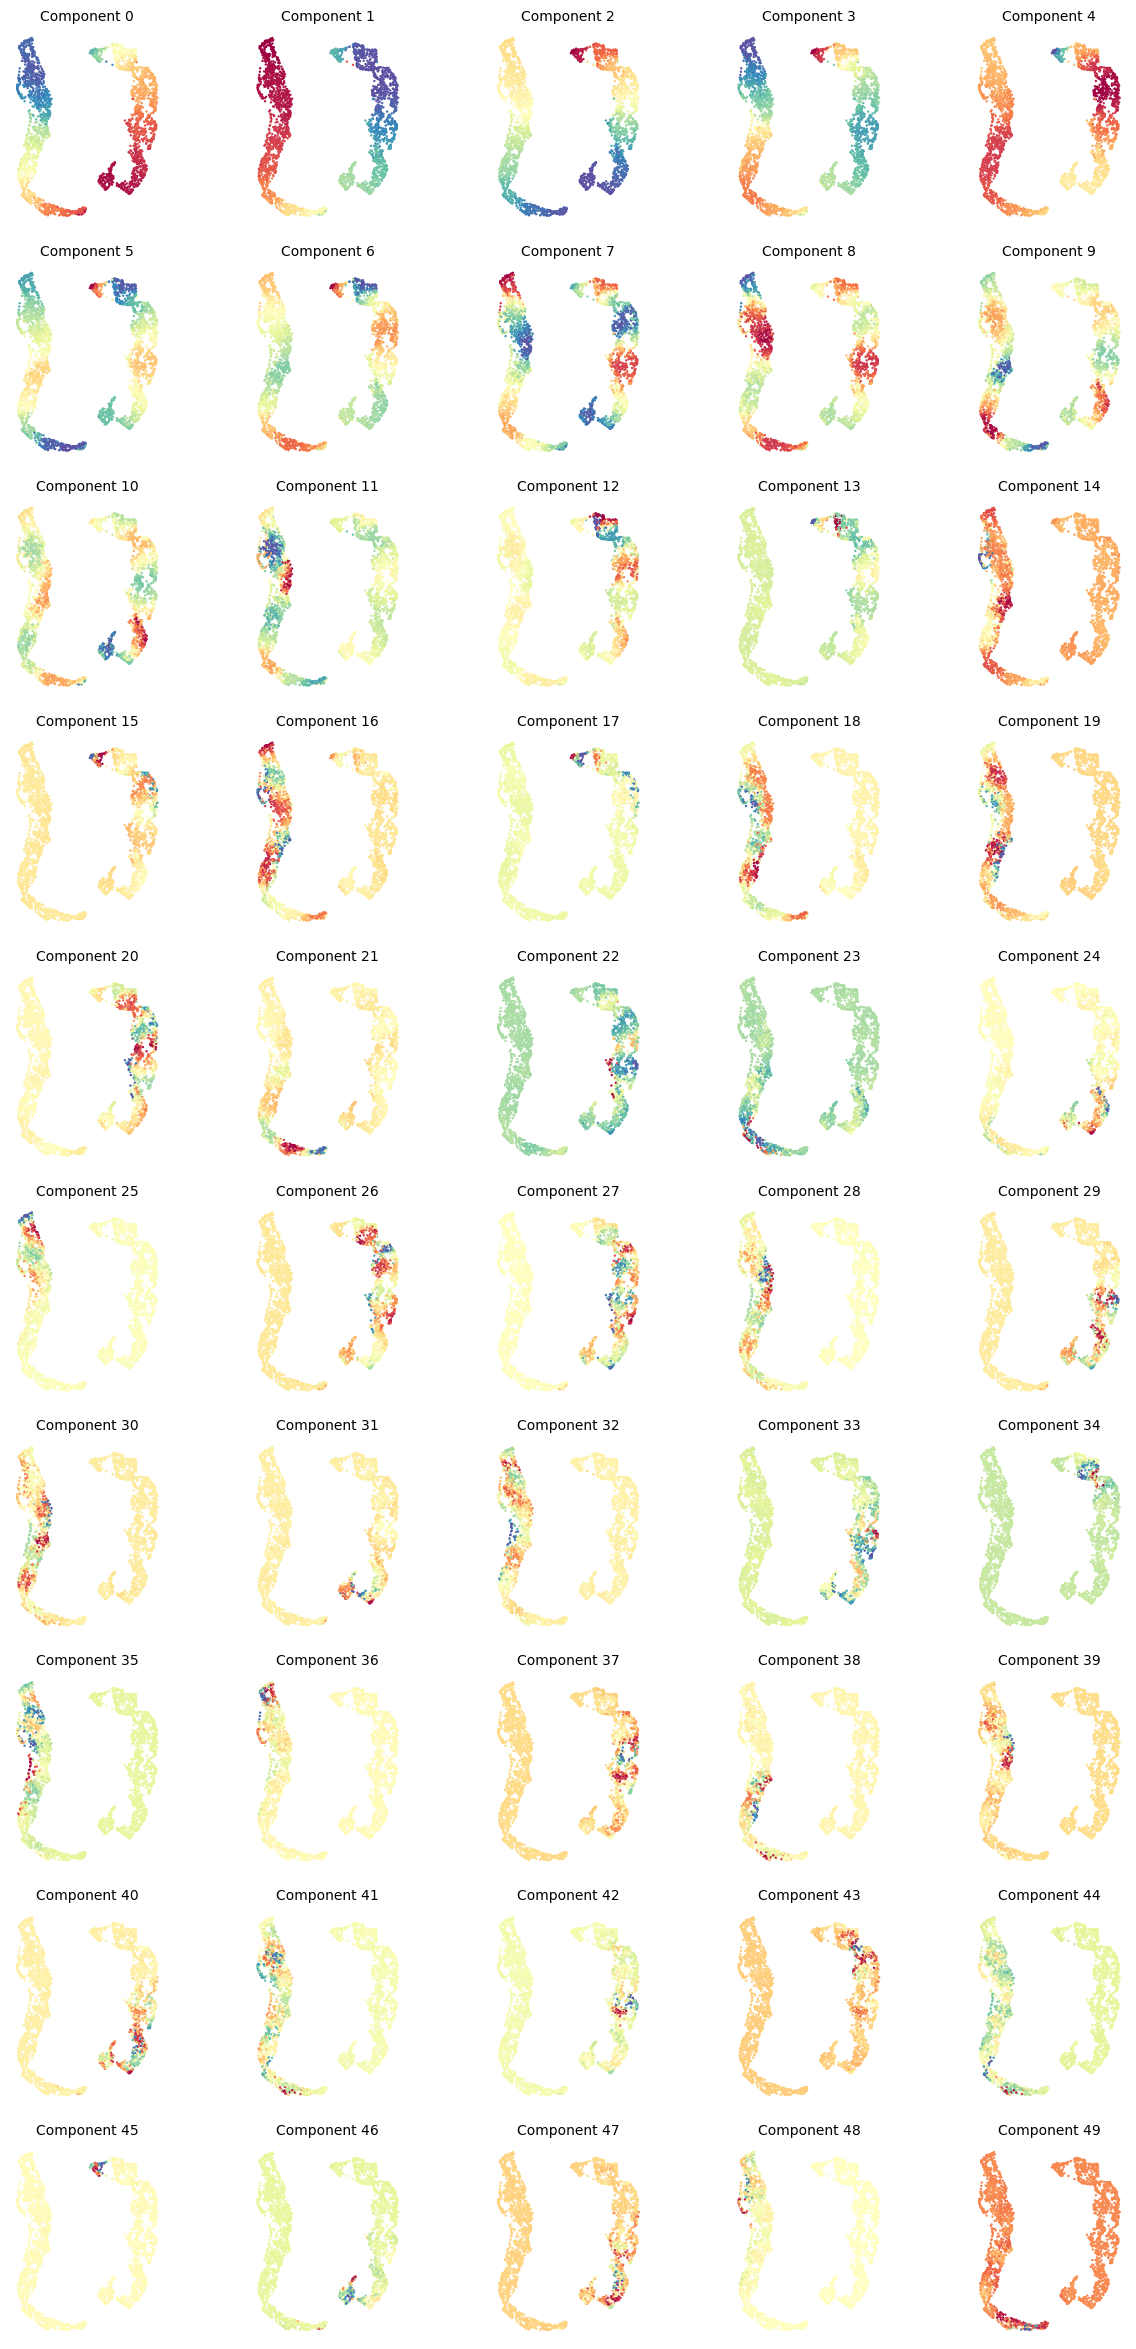

In [55]:
palantir.plot.plot_diffusion_components(CELLS)
plt.show()

Names for cells in spermatogoniaA to choose from

In [56]:
CELLS[CELLS.obs['clusters_single']=='SpermatogoniaA'].obs_names

Index(['AACCACAGTGCAGATG-Cells', 'AACGAAAGTACGACTT-Cells',
       'AAGCATCTCACTAGCA-Cells', 'AAGGTAATCTGGCCTT-Cells',
       'AATCACGCAGAGTCTT-Cells', 'ACACTGAAGCTCGTGC-Cells',
       'ACATGCAAGGACGGAG-Cells', 'ACATGCATCCATACAG-Cells',
       'ACCCTCAGTTACCCTC-Cells', 'ACCTGAACACAATGTC-Cells',
       'ACTGATGTCTCGTTTA-Cells', 'ACTTAGGGTATGCTAC-Cells',
       'AGAGAATGTGTTACAC-Cells', 'AGCCAGCAGAAATGGG-Cells',
       'AGCCAGCTCTGCGGCA-Cells', 'AGCTCAATCCCAGGCA-Cells',
       'AGGGAGTGTAAGTCAA-Cells', 'AGTACCATCCCAGGCA-Cells',
       'AGTAGCTTCGTCAGAT-Cells', 'ATCACTTGTGACCGAA-Cells',
       'ATTACTCTCGGAAGGT-Cells', 'ATTCAGGTCTAAGAAG-Cells',
       'ATTCCTATCGACGCGT-Cells', 'CAGAGCCCATCACGGC-Cells',
       'CAGATCATCACCTGTC-Cells', 'CAGCCAGCATCGCTGG-Cells',
       'CAGGTATCATCCGATA-Cells', 'CAGTTCCGTTATTCCT-Cells',
       'CATCGCTCAAACGTGG-Cells', 'CATGCTCCACAGTACT-Cells',
       'CCGGACATCATCGCAA-Cells', 'CCTAACCTCCTAAGTG-Cells',
       'CGAGTTATCTTTACAC-Cells', 'CGGAATTCAGTAGAAT-Cells

In [57]:
start_cell = 'TTGGGTATCTTTGGAG-Cells'
pr_res = palantir.core.run_palantir( CELLS, early_cell=start_cell, 
                                    knn=20, seed=123, num_waypoints=100, 
)

Sampling and flocking waypoints...
Time for determining waypoints: 4.2939186096191405e-05 minutes
Determining pseudotime...
Shortest path distances using 20-nearest neighbor graph...
Time for shortest paths: 0.7485277573267619 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9997
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


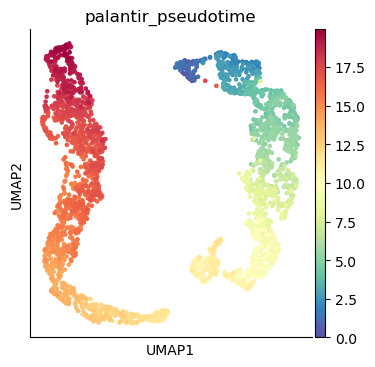

In [58]:
sc.pl.umap(CELLS, color=['palantir_pseudotime'])

In [59]:
CELLS.obs['dpt_palantir']=CELLS.obs['palantir_pseudotime']/max(CELLS.obs['palantir_pseudotime'])

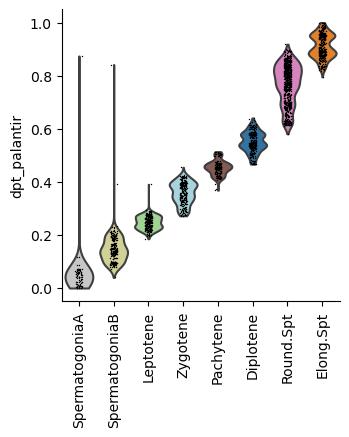

In [60]:
sc.pl.violin(CELLS, keys='dpt_palantir', groupby='clusters_single',
             order=['SpermatogoniaA','SpermatogoniaB','Leptotene','Zygotene',
                   'Pachytene','Diplotene','Round.Spt',
                   'Elong.Spt'], rotation=90)

In [61]:
avoid = ((CELLS.obs['clusters_single']=='SpermatogoniaA')&(CELLS.obs['dpt_palantir']>.2))|((CELLS.obs['clusters_single']=='SpermatogoniaB')&(CELLS.obs['dpt_palantir']>.3))
CELLS = CELLS[ np.invert(avoid) ].copy()

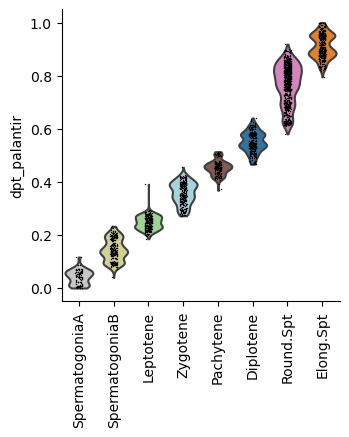

In [62]:
sc.pl.violin(CELLS, keys='dpt_palantir', groupby='clusters_single',
             order=['SpermatogoniaA','SpermatogoniaB','Leptotene','Zygotene',
                   'Pachytene','Diplotene','Round.Spt',
                   'Elong.Spt'], rotation=90)

## Pseudotime for nuclei

### Palantir

In [63]:
import palantir

In [64]:
NUCLEI.obsm['X_pca'] = NUCLEI.obsm['X_DM'][:,0:50].copy()

In [65]:
NUCLEI.obs.clusters_single.cat.categories

Index(['Diplotene', 'Elong.Spt', 'Leptotene', 'Myoid', 'Pachytene',
       'Round.Spt', 'SpermatogoniaA', 'SpermatogoniaB', 'Zygotene'],
      dtype='object')

In [84]:
NUCLEI_2 = NUCLEI[ [i not in ['Myoid'] for i in NUCLEI.obs['clusters_single']] ].copy()

In [85]:
# Run diffusion maps
dm_res = palantir.utils.run_diffusion_maps(NUCLEI_2, n_components=50)

In [86]:
ms_data = palantir.utils.determine_multiscale_space(NUCLEI_2)

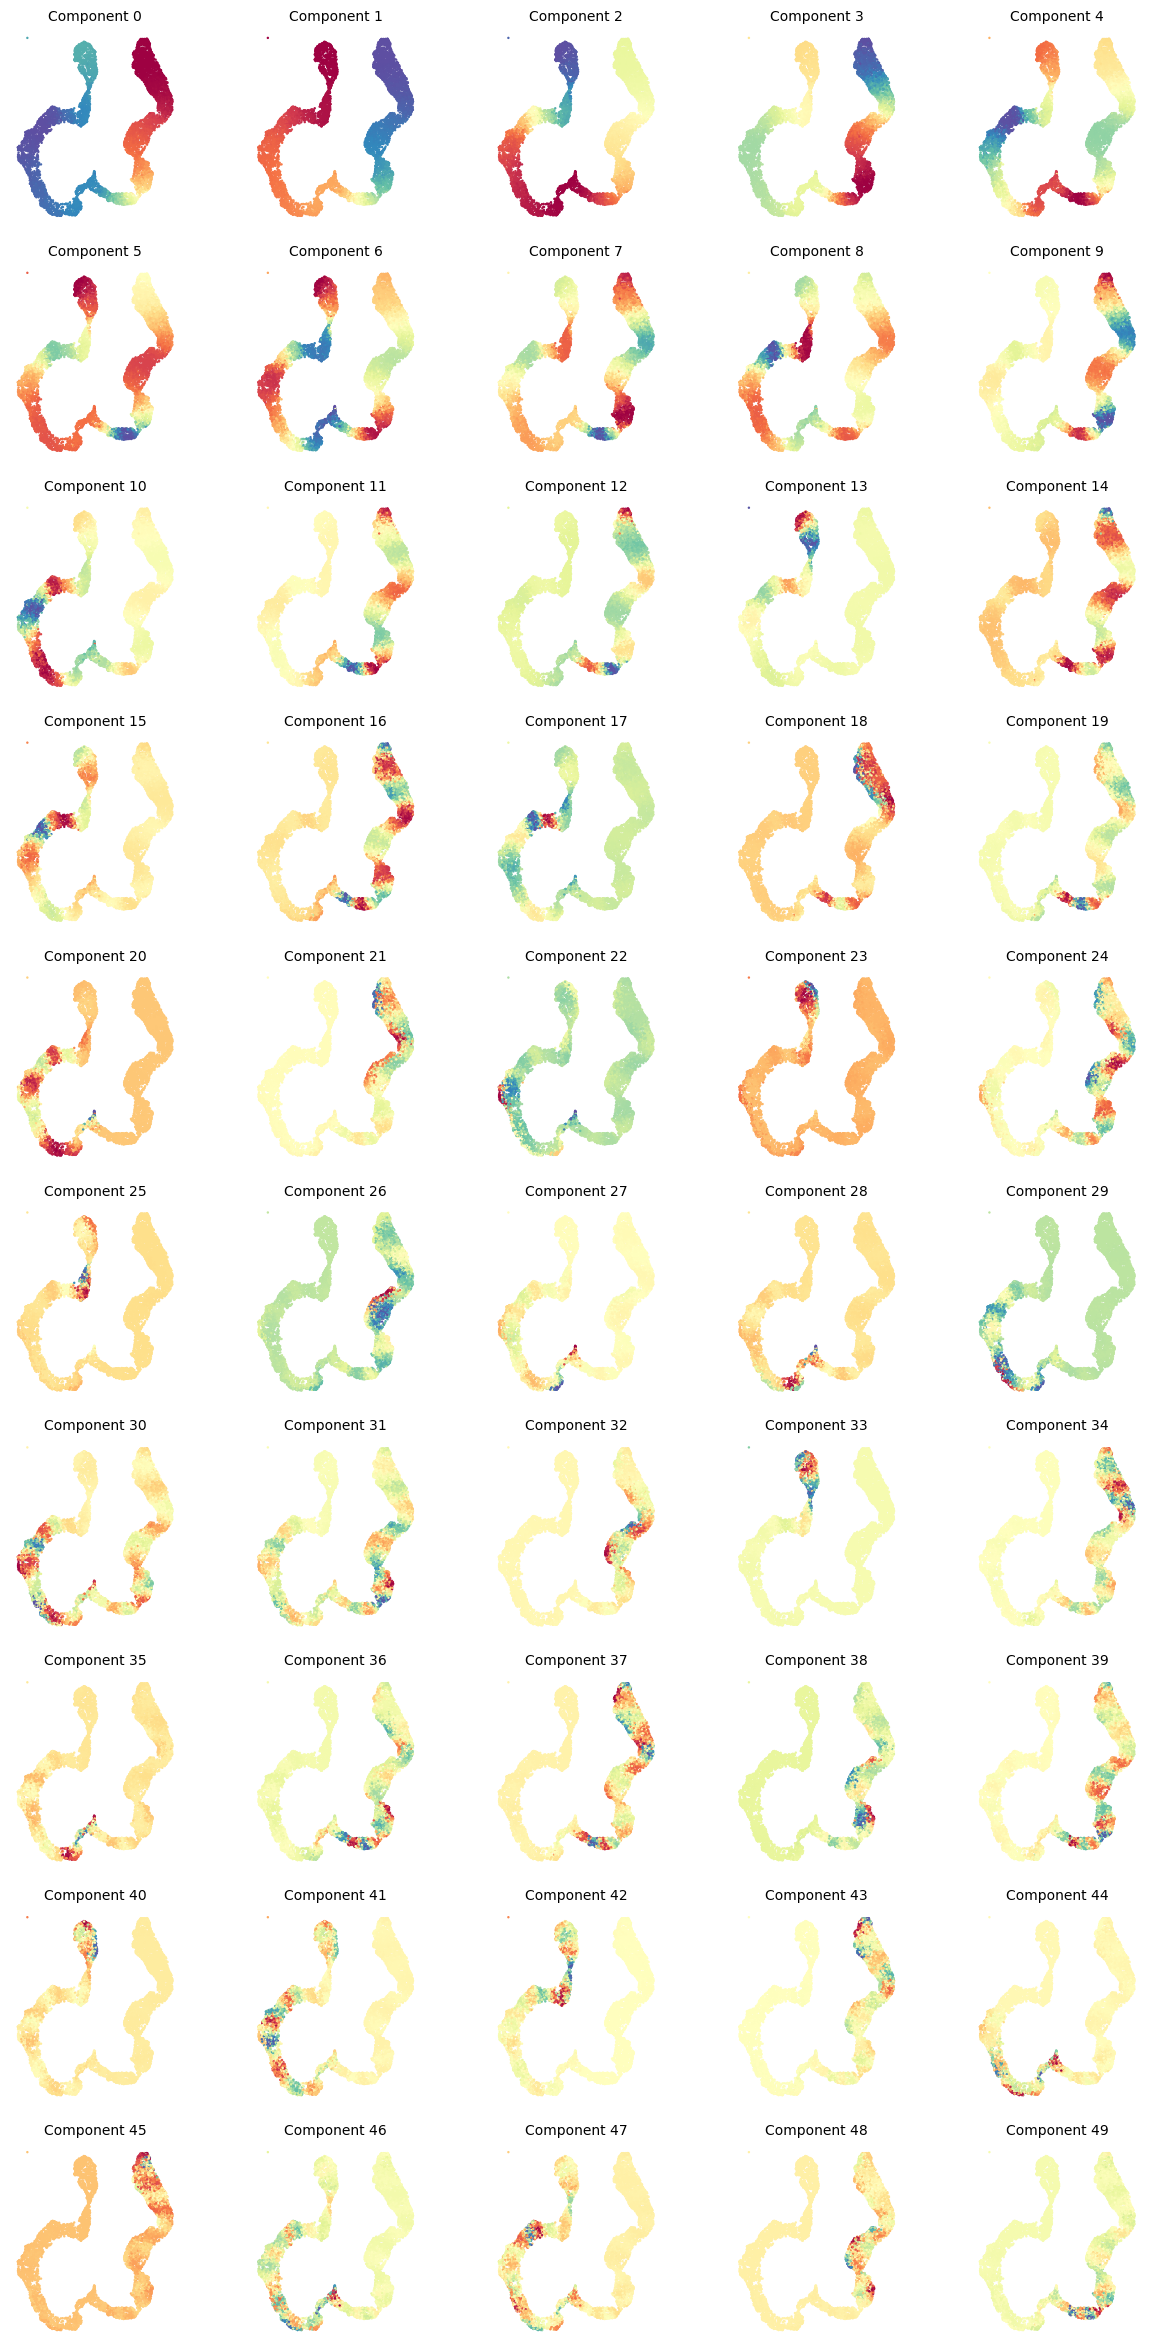

In [87]:
palantir.plot.plot_diffusion_components(NUCLEI_2)
plt.show()

Names for nuclei in spermatogoniaA to choose from

In [88]:
NUCLEI_2[NUCLEI_2.obs['clusters_single']=='SpermatogoniaA'].obs_names

Index(['AAACCCACAGATCCTA-Nuclei', 'AAACGCTGTTCCATTT-Nuclei',
       'AAAGAACGTCAACCTA-Nuclei', 'AAAGGGCTCCTGCCAT-Nuclei',
       'AAAGTGATCTGAGTCA-Nuclei', 'AACAACCAGGGACTGT-Nuclei',
       'AACAGGGTCCACGAAT-Nuclei', 'AACCCAAAGCCGTTAT-Nuclei',
       'AACGGGAAGGATCACG-Nuclei', 'AACGGGACACCGCTAG-Nuclei',
       ...
       'TTGTGGAGTCTTGAGT-Nuclei', 'TTGTGTTCAAGCACCC-Nuclei',
       'TTGTGTTCACGCTGAC-Nuclei', 'TTGTTGTAGAAGGATG-Nuclei',
       'TTGTTTGAGTGGAAGA-Nuclei', 'TTTACCATCTAGTTCT-Nuclei',
       'TTTCACACACCGTACG-Nuclei', 'TTTCACATCAGCAATC-Nuclei',
       'TTTCATGGTGACCTGC-Nuclei', 'TTTCCTCAGAGTCAAT-Nuclei'],
      dtype='object', length=639)

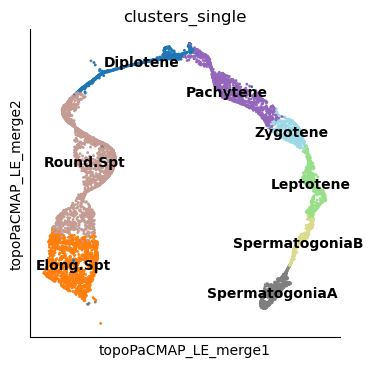

In [89]:
plt.rcParams["figure.figsize"] = (4, 4)
sc.pl.embedding(
    NUCLEI_2,
    basis="topoPaCMAP_LE_merge",
    color=['clusters_single'],
    palette="tab20",
    ncols=2,
    legend_loc="on data",
    legend_fontsize=10,
)

In [90]:
start_cell = 'AAAGAACGTCAACCTA-Nuclei'
pr_res = palantir.core.run_palantir( NUCLEI_2, early_cell=start_cell, 
                                    knn=50, seed=123, num_waypoints=100, 
)

Sampling and flocking waypoints...
Time for determining waypoints: 0.00016902685165405275 minutes
Determining pseudotime...
Shortest path distances using 50-nearest neighbor graph...
Time for shortest paths: 0.0665213942527771 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9999
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


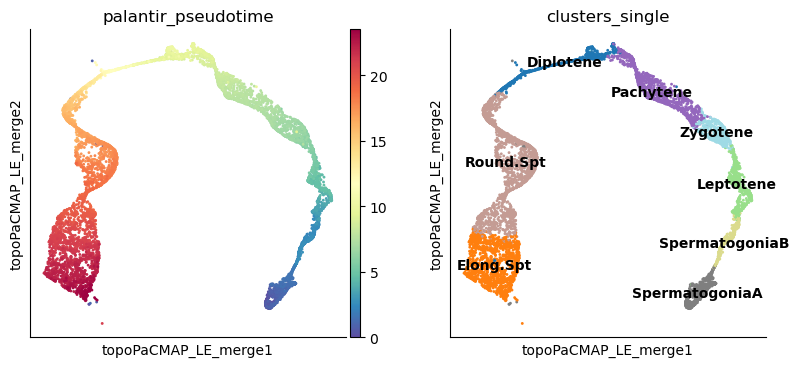

In [91]:
plt.rcParams["figure.figsize"] = (4, 4)
sc.pl.embedding(
    NUCLEI_2,
    basis="topoPaCMAP_LE_merge",
    color=['palantir_pseudotime', 'clusters_single'],
    palette="tab20",
    ncols=2,
    legend_loc="on data",
    legend_fontsize=10,
)

In [74]:
NUCLEI_2.obs['dpt_palantir']=NUCLEI_2.obs['palantir_pseudotime']/max(NUCLEI_2.obs['palantir_pseudotime'])

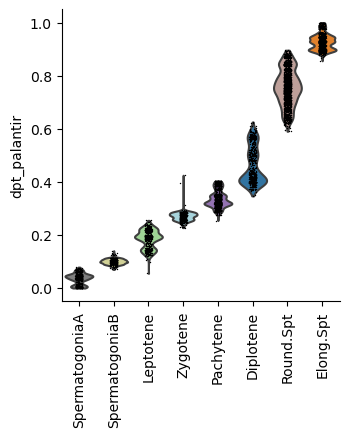

In [92]:
sc.pl.violin(NUCLEI_2, keys='dpt_palantir', groupby='clusters_single',
             order=['SpermatogoniaA','SpermatogoniaB','Leptotene','Zygotene',
                   'Pachytene','Diplotene','Round.Spt',
                   'Elong.Spt'], rotation=90)

In [93]:
avoid2 = ((NUCLEI_2.obs['clusters_single']=='SpermatogoniaA')&(NUCLEI_2.obs['dpt_palantir']>.1)) |\
         ((NUCLEI_2.obs['clusters_single']=='SpermatogoniaB')&(NUCLEI_2.obs['dpt_palantir']>.2)) |\
         ((NUCLEI_2.obs['clusters_single']=='Leptotene')&(NUCLEI_2.obs['dpt_palantir']>.3)) |\
         ((NUCLEI_2.obs['clusters_single']=='Zygotene')&(NUCLEI_2.obs['dpt_palantir']>.35)) |\
         ((NUCLEI_2.obs['clusters_single']=='Pachytene')&(NUCLEI_2.obs['dpt_palantir']>.4)) |\
         ((NUCLEI_2.obs['clusters_single']=='Diplotene')&(NUCLEI_2.obs['dpt_palantir']>.65)) |\
         ((NUCLEI_2.obs['clusters_single']=='Round.Spt')&(NUCLEI_2.obs['dpt_palantir']>.95))
NUCLEI_2 = NUCLEI_2[ np.invert(avoid2) ].copy()

Note now we put the pseudotimes in the dataset NUCLEI with value -1 for the myoid cells

In [94]:
dpt_palantir_new = pd.Series(index=NUCLEI.obs_names)
dpt_palantir_new[NUCLEI_2.obs_names] = NUCLEI_2.obs.dpt_palantir
dpt_palantir_new[ [i not in NUCLEI_2.obs_names for i in NUCLEI.obs_names]  ] = -1

In [95]:
NUCLEI.obs['dpt_palantir'] = dpt_palantir_new.copy()

Remove the outliers but keep the myoids

In [96]:
NUCLEI = NUCLEI[ np.concatenate( [np.array(NUCLEI_2.obs_names), np.array(NUCLEI[ [i in ['Myoid'] for i in NUCLEI.obs.clusters_single] ].obs_names)]) ].copy()

In [97]:
adata = adata[ np.concatenate( [np.array(NUCLEI.obs_names),np.array(CELLS.obs_names)] ) ].copy()

In [98]:
adata.shape

(9918, 23544)

In [99]:
adata.obs['dpt_palantir'] = np.concatenate( (NUCLEI.obs['dpt_palantir'],CELLS.obs['dpt_palantir']) )

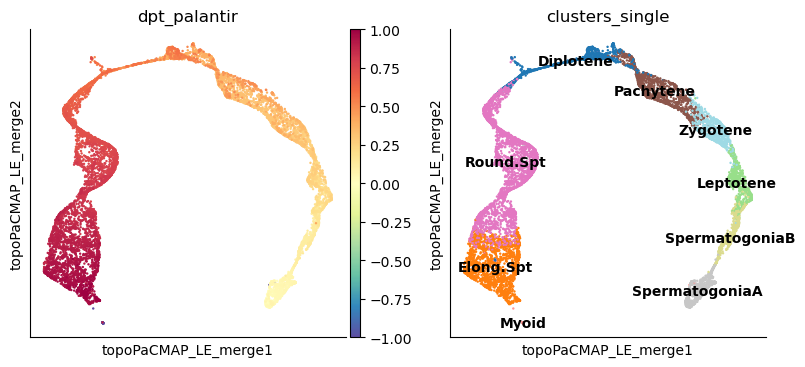

In [101]:
plt.rcParams["figure.figsize"] = (4, 4)
sc.pl.embedding(
    adata,
    basis="topoPaCMAP_LE_merge",
    color=['dpt_palantir', 'clusters_single'],
    palette="tab20",
    ncols=2,
    legend_loc="on data",
    legend_fontsize=10,
)

## Pseudotime alignment


subsetting the data

In [102]:
adata_flt = adata[:,adata.var.highly_variable].copy()

In [103]:
adata_flt = adata_flt[ [i not in ['Myoid'] for i in adata_flt.obs.clusters_single] ].copy()

In [104]:
adata_flt.layers

Layers with keys: SCT_counts, correct_counts, raw_counts, soupx_Z_counts, soupx_counts, spliced, unspliced

In [105]:
adata_flt.X = adata_flt.layers['SCT_counts'].copy()
#sc.pp.scale(adata_flt)

preparing all the things to pass to R

- cells and nuclei matrices

In [106]:
cellMat=adata_flt[adata_flt.obs['batch']=='Cells'].X.copy()

In [107]:
nucMat=adata_flt[adata_flt.obs['batch']=='Nuclei'].X.copy()

- barcode names

In [108]:
cellNames = np.array(adata_flt[adata_flt.obs['batch']=='Cells'].obs_names)

In [109]:
nucNames = np.array(adata_flt[adata_flt.obs['batch']=='Nuclei'].obs_names)

- pseudotimes

In [110]:
cellT = np.array(adata_flt[ [i in ['Cells'] for i in adata_flt.obs.batch] ].obs['dpt_palantir'])

In [111]:
nucT = np.array(adata_flt[ [i in ['Nuclei'] for i in adata_flt.obs.batch] ].obs['dpt_palantir'])

Running `cellAlign` in `R`

- create the two objects with pseudotimes 

In [112]:
%%R -i cellMat -i nucMat -i cellT -i nucT -i nucNames -i cellNames

library(cellAlign)

cellT = as.numeric(cellT)
nucT = as.numeric(nucT)
#give names to the matrices (invert rows and cols when used as input)
names(cellT) = cellNames
names(nucT) = nucNames
rownames(cellMat) = cellNames; #colnames(cellMat) = genes_inters
rownames(nucMat) = nucNames; #colnames(nucMat) = genes_inters

#number of alignment points when binning time interval
numPts = 50
#Cell data
cellData = cellAlign::interWeights(expDataBatch = t(cellMat), trajCond = cellT,
                                         winSz = 0.1, numPts = numPts)
#Nuclei data
nucData = cellAlign::interWeights(expDataBatch = t(nucMat), trajCond = nucT,
                                         winSz = 0.1, numPts = numPts)

- calculate the trajectory

In [113]:
%%R

require(ggplot2)
require(reshape2)
require(pheatmap)

# this is just to plot rudimentally the behaviour of a chosen gene (first in the list). 
#T he behaviour will actually be modelled with 
# a GAM, but what we do here is just representative

#sharedMarkers = intersect(rownames(t(cellMat)), rownames(t(nucMat)))
#whichgene=sharedMarkers[100]
selectedCell<-cellData$interpolatedVals[1,]#[whichgene,]
selectedNuc<-nucData$interpolatedVals[1,]#[whichgene,]

dfCelli = data.frame(traj = cellData$traj, value=c(selectedCell), error=c(cellData$error[1,]))
dfCell = data.frame(traj = cellT, cellMat[,1])
dfNuci = data.frame(traj = nucData$traj, value=c(selectedNuc), error=c(nucData$error[1,]))
dfNuc = data.frame(traj = nucT, nucMat[,1])
dfCellM = melt(dfCell, id.vars = 'traj')
dfNucM = melt(dfNuc, id.vars = 'traj')


R[write to console]: Loading required package: ggplot2

R[write to console]: Loading required package: reshape2

R[write to console]: Loading required package: pheatmap



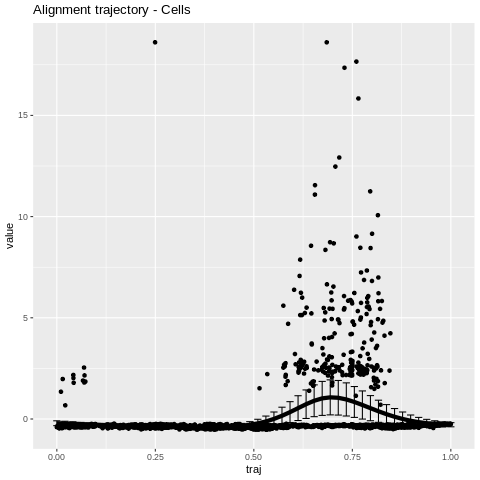

In [114]:
%%R

#plot of an example gene and its interpolation with error bars
ggplot(dfCelli, aes(x=traj,y=value)) +  
    geom_errorbar(aes(ymin=value-error/2, ymax=value+error/2)) + 
    geom_line(size = 2) + 
    geom_point(data=dfCellM, aes(x=traj,y=value)) + 
    ggtitle("Alignment trajectory - Cells") 

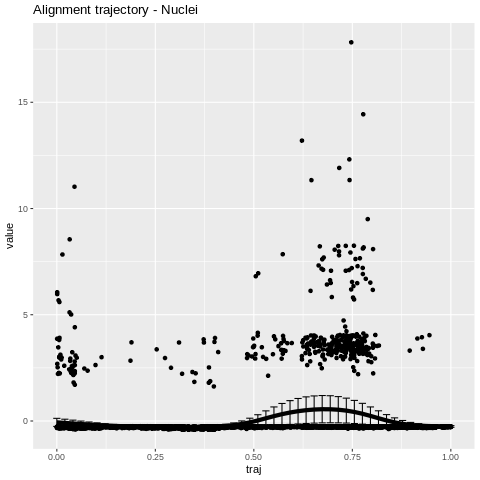

In [115]:
%%R

#plot of an example gene and its interpolation with error bars
ggplot(dfNuci, aes(x=traj,y=value)) +  
    geom_errorbar(aes(ymin=value-error/2, ymax=value+error/2)) + 
    geom_line(size = 2) + 
    geom_point(data=dfNucM, aes(x=traj,y=value)) + 
    ggtitle("Alignment trajectory - Nuclei") 

- plot the distances between bins of pseudotimes

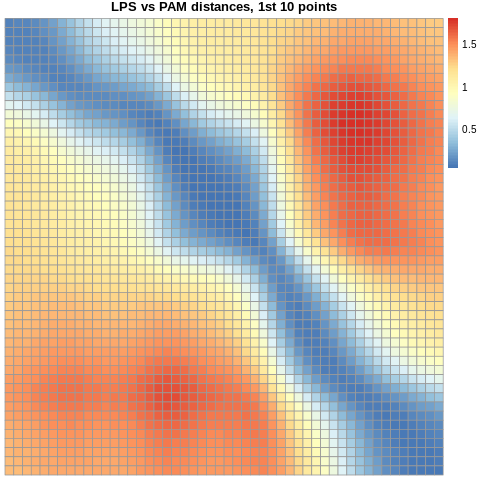

In [116]:
%%R
A=calcDistMat(nucData$interpolatedVals,cellData$interpolatedVals, dist.method = 'Cosine')
pheatmap(A, cluster_cols = F, cluster_rows=F, main = "LPS vs PAM distances, 1st 10 points",
          show_rownames = T, show_colnames = T,display_numbers = F)

R[write to console]: calculate dissimilarity matrix

R[write to console]: calculate cost and step matrices

R[write to console]: backtracking



[1] NA


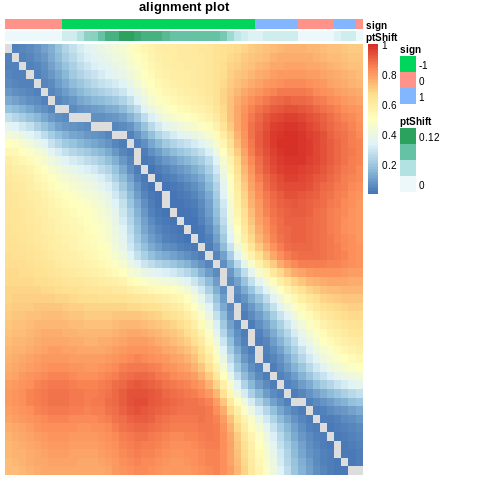

In [117]:
%%R

alignment = globalAlign(nucData$interpolatedVals, cellData$interpolatedVals,
                                   scores = list(query = nucData$traj, 
                                                 ref = cellData$traj),
                                   sigCalc = F, numPerm = 20, dist.method = "Cosine")
plotAlign(alignment)

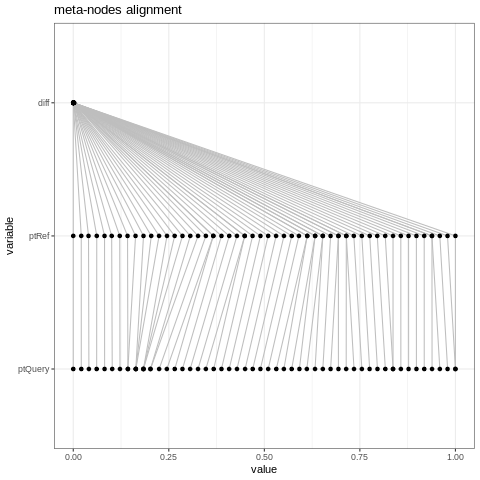

In [118]:
%%R

mapping = mapRealDataGlobal(alignment,intTrajQuery = nucData$traj, realTrajQuery = nucT,
                            intTrajRef = cellData$traj, realTrajRef = cellT)
plotMapping(mapping)

In [119]:
%%R -o mapping
ls(mapping)

[1] "metaNodesPt" "queryAssign" "refAssign"  


In [121]:
mapping['metaNodesPt']['diff']

1     0.000000
2     0.000076
3     0.000967
4     0.000246
5     0.000202
6     0.001450
7     0.000603
8     0.000870
9     0.000314
10    0.000260
11    0.000419
12    0.000355
13    0.000369
14    0.000016
15    0.000056
16    0.002248
17    0.002067
18    0.000166
19    0.000796
20    0.001182
21    0.000050
22    0.000234
23    0.000214
24    0.000307
25    0.000401
26    0.000072
27    0.000201
28    0.000018
29    0.000490
30    0.000081
31    0.000451
32    0.001275
33    0.000649
34    0.000030
35    0.000132
36    0.000417
37    0.001064
38    0.000053
39    0.000003
40    0.000045
41    0.000092
42    0.000268
43    0.000208
44    0.000591
45    0.000045
46    0.000216
47    0.000685
48    0.000013
49    0.000014
50    0.000113
51    0.000158
52    0.000073
53    0.000128
54    0.000274
55    0.000175
56    0.000048
57    0.000234
58    0.000000
Name: diff, dtype: float64

In [122]:
cellDF = pd.DataFrame(np.array(mapping['metaNodesPt']['ptRef']), 
                      index=mapping['metaNodesPt']['metaNodeRef']  )

In [123]:
nucDF = pd.DataFrame(np.array(mapping['metaNodesPt']['ptQuery']), 
                      index=mapping['metaNodesPt']['metaNodeQuery']  )

In [124]:
nucNodes = pd.Series(index=nucNames)
cellNodes = pd.Series(index=cellNames)
for n,c,Tn,Tc in zip(nucDF.index, cellDF.index, nucDF[0], cellDF[0]):
    nucNodes[ mapping['queryAssign'][n] ] = Tn
    cellNodes[ mapping['refAssign'][c] ] = Tc

In [125]:
nucNodes

AAACCCAAGGACAGCT-Nuclei    0.897946
AAACCCACAGATCCTA-Nuclei    0.040901
AAACCCAGTTAGTCGT-Nuclei    0.265628
AAACGAAAGAGCATAT-Nuclei    0.428407
AAACGAAAGCTATCCA-Nuclei    0.285712
                             ...   
TTTGTTGCACTGCGAC-Nuclei    0.959206
TTTGTTGGTCCAGCAC-Nuclei    0.531297
TTTGTTGGTCCGTACG-Nuclei    0.693874
TTTGTTGTCGTACACA-Nuclei    0.265628
TTTGTTGTCTGGCCGA-Nuclei    0.142934
Length: 7174, dtype: float64

How to check Nan in the alignment and correction with the nearest neighbour (not a problem in this case)

In [126]:
idxNan = nucNodes.index[ np.where(np.isnan(nucNodes)) ]

In [127]:
idxNan

Index([], dtype='object')

In [128]:
idxNan = cellNodes.index[ np.where(np.isnan(cellNodes)) ]

In [129]:
idxNan

Index([], dtype='object')

correction:

In [130]:
#dist = pd.DataFrame( NUCLEI.uns['neighbors']['distances'].todense(), 
#                    index=adata_flt[adata_flt.obs['condition']=='nuclei'].obs_names,
#                    columns=adata_flt[adata_flt.obs['condition']=='nuclei'].obs_names )


In [131]:
#for i in idxNan:
#    gzero = dist.loc[i,:][ dist.loc[i,:]>0 ]
#    nucNodes.loc[ i ] = nucNodes.loc[ np.argmin(gzero) ]

Copying all the binned aligned pseudotimes in the original data object

In [132]:
concatTime = pd.concat([nucNodes, cellNodes])

In [133]:
dpt_cellalign_new = pd.Series(index=adata.obs_names)
dpt_cellalign_new[adata_flt.obs_names] = concatTime

In [134]:
dpt_cellalign_new[ [i not in adata_flt.obs_names for i in dpt_cellalign_new.index] ] = -1

In [135]:
adata.obs['dpt_palantir_cellalign'] = dpt_cellalign_new.copy()

Some fancy plots

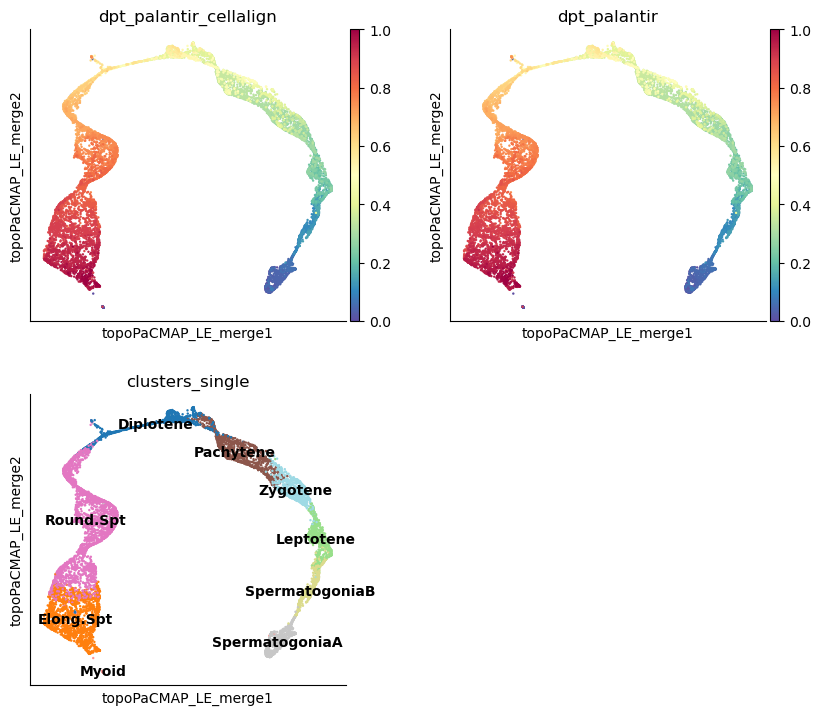

In [136]:
plt.rcParams["figure.figsize"] = (4, 4)
sc.pl.embedding(
    adata,
    basis="topoPaCMAP_LE_merge",
    color=['dpt_palantir_cellalign', 'dpt_palantir', 'clusters_single'],
    palette="tab20",
    ncols=2,
    legend_loc="on data",
    legend_fontsize=10,
    vmin=0
)

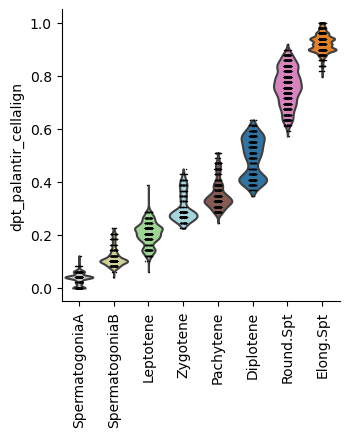

In [137]:
sc.pl.violin(adata, keys='dpt_palantir_cellalign', groupby='clusters_single',
             order=['SpermatogoniaA','SpermatogoniaB','Leptotene','Zygotene',
                   'Pachytene','Diplotene','Round.Spt',
                   'Elong.Spt'], rotation=90)

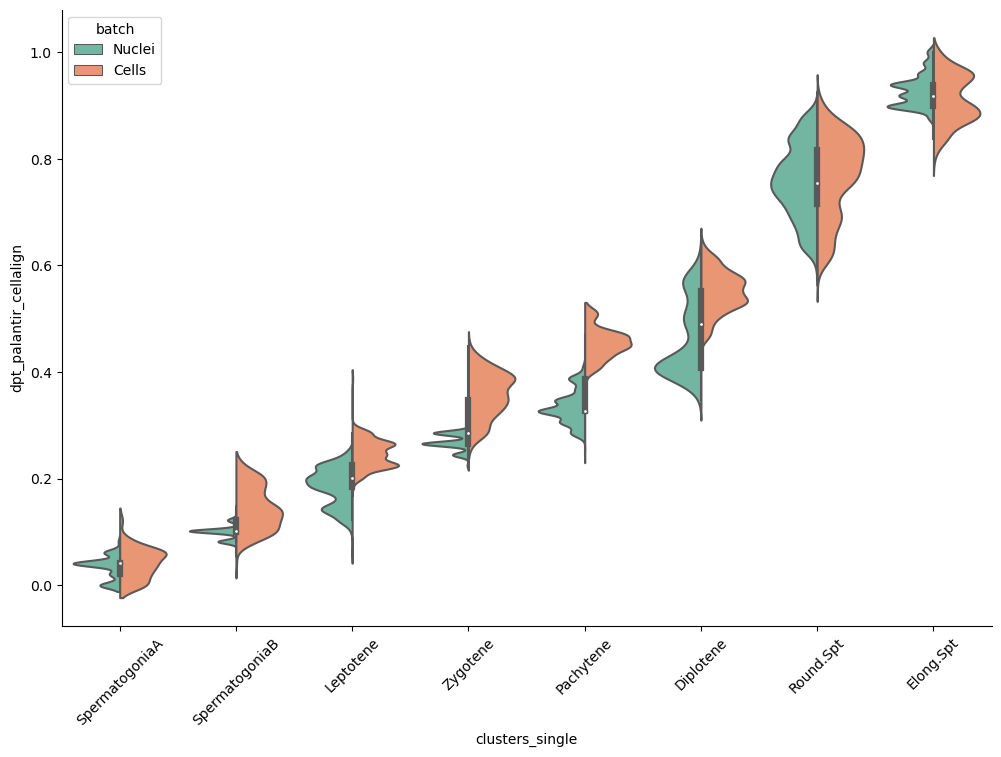

In [138]:
fig, (ax1) = plt.subplots(1, 1, figsize=(12,8), gridspec_kw={'wspace':0.5})
ax = sns.violinplot(x="clusters_single", y="dpt_palantir_cellalign", hue="batch", 
                    scale="width", palette="Set2", split=True, ax=ax1,                    
                    data=adata.obs[ ['batch', 'dpt_palantir_cellalign', 'clusters_single'] ], 
                    order=['SpermatogoniaA','SpermatogoniaB','Leptotene','Zygotene',
                   'Pachytene','Diplotene','Round.Spt',
                   'Elong.Spt'])
ax.tick_params(axis='x', rotation=45)

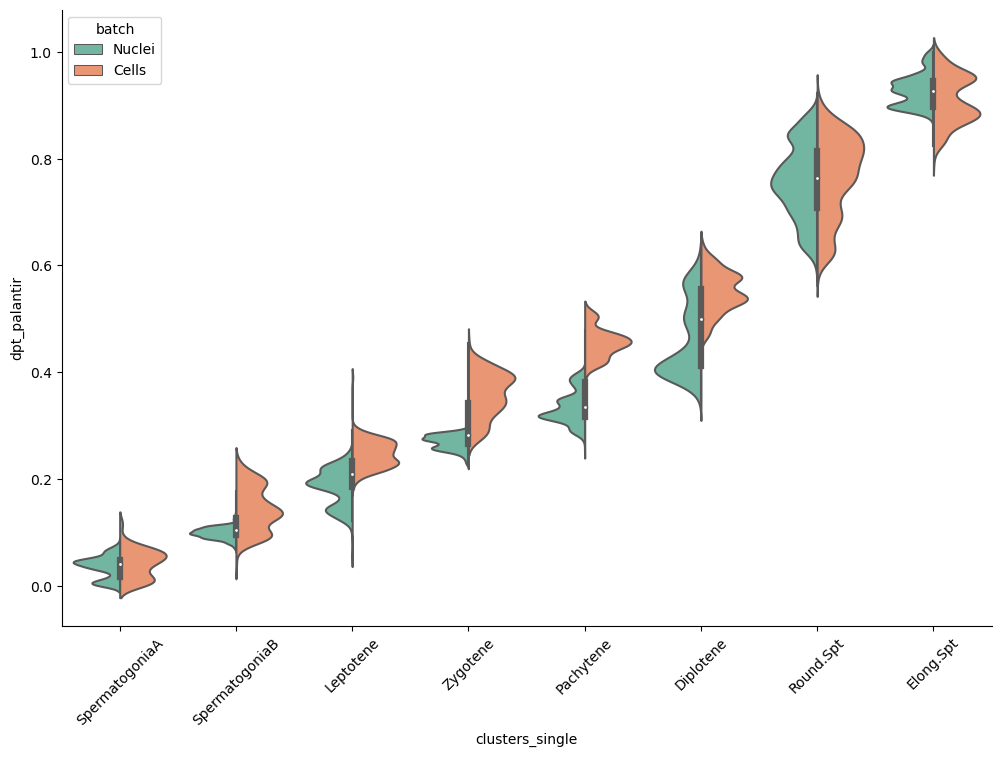

In [139]:
fig, (ax1) = plt.subplots(1, 1, figsize=(12,8), gridspec_kw={'wspace':0.5})
ax = sns.violinplot(x="clusters_single", y="dpt_palantir", hue="batch", 
                    scale="width", palette="Set2", split=True, ax=ax1,                    
                    data=adata.obs[ ['batch', 'dpt_palantir', 'clusters_single'] ], 
                    order=['SpermatogoniaA','SpermatogoniaB','Leptotene','Zygotene',
                   'Pachytene','Diplotene','Round.Spt',
                   'Elong.Spt'])
ax.tick_params(axis='x', rotation=45)

In [140]:
adata.write('./write/adata.dpt.h5ad')

We also look at size of differences between pseudotimes to see the size of the correction

In [141]:
adata = sc.read('./write/adata.dpt.h5ad')

In [142]:
nucDF = pd.DataFrame(np.array(mapping['metaNodesPt']['diff']), 
                      index=mapping['metaNodesPt']['metaNodeQuery']  )

In [143]:
nucNodes = pd.Series(index=nucNames)
for n,Tn in zip(nucDF.index, nucDF[0]):
    nucNodes[ mapping['queryAssign'][n] ] = Tn

In [144]:
nucNodes

AAACCCAAGGACAGCT-Nuclei    0.000073
AAACCCACAGATCCTA-Nuclei    0.000967
AAACCCAGTTAGTCGT-Nuclei    0.001182
AAACGAAAGAGCATAT-Nuclei    0.000018
AAACGAAAGCTATCCA-Nuclei    0.000050
                             ...   
TTTGTTGCACTGCGAC-Nuclei    0.000175
TTTGTTGGTCCAGCAC-Nuclei    0.000649
TTTGTTGGTCCGTACG-Nuclei    0.000092
TTTGTTGTCGTACACA-Nuclei    0.001182
TTTGTTGTCTGGCCGA-Nuclei    0.000314
Length: 7174, dtype: float64

In [145]:
NUCLEI.obs['dpt_diff'] = [nucNodes[i] if i in nucNodes.index 
                          else -1
                          for i in NUCLEI.obs_names]

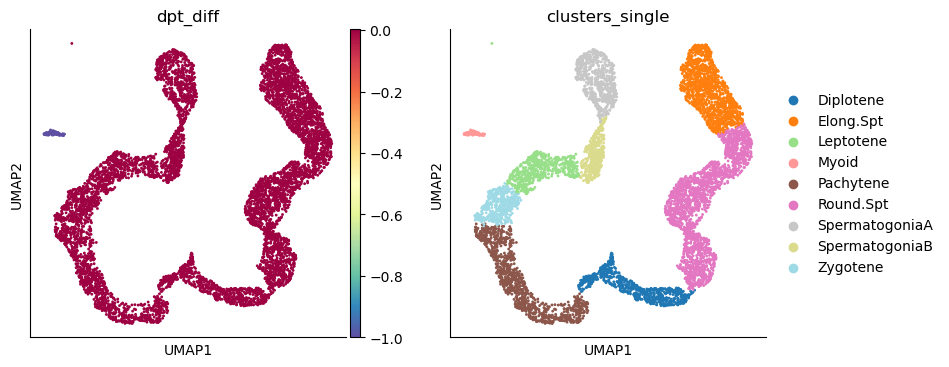

In [146]:
sc.pl.umap(NUCLEI, color=['dpt_diff','clusters_single'])

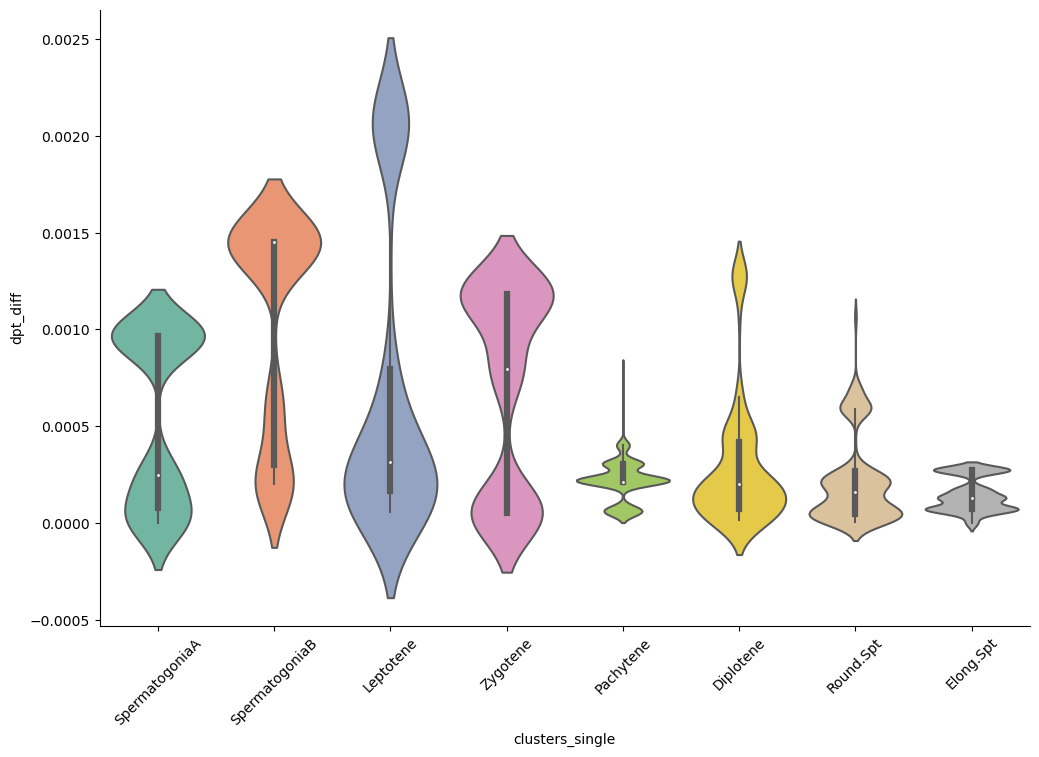

In [147]:
fig, (ax1) = plt.subplots(1, 1, figsize=(12,8), gridspec_kw={'wspace':0.5})
ax = sns.violinplot(x="clusters_single", y="dpt_diff", 
                    scale="width", palette="Set2", ax=ax1,                    
                    data=NUCLEI.obs[ ['dpt_diff', 'clusters_single'] ], 
                    order=['SpermatogoniaA','SpermatogoniaB','Leptotene','Zygotene',
                   'Pachytene','Diplotene','Round.Spt',
                   'Elong.Spt'])
ax.tick_params(axis='x', rotation=45)

Almost no corrections in the alignment

## With imputation

Testing the pseudotimes adding imputation with MAGIC to see how pseudotimes change for nuclei, and if the differences by clusters are due to dropouts

In [148]:
adata = sc.read('./write/adata.dpt.h5ad')

In [149]:
NUCLEI = adata[adata.obs['batch']=='Nuclei'].copy()
CELLS = adata[adata.obs['batch']=='Cells'].copy()

In [150]:
import magic

In [151]:
magic_op = magic.MAGIC()

imputation

In [152]:
CELLS_magic = magic_op.fit_transform( np.array(CELLS.layers['soupx_counts']) )

Calculating MAGIC...
  Running MAGIC on 2676 cells and 23544 genes.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 5.43 seconds.
    Calculating KNN search...
    Calculated KNN search in 0.45 seconds.
    Calculating affinities...
    Calculated affinities in 0.44 seconds.
  Calculated graph and diffusion operator in 6.32 seconds.
  Running MAGIC with `solver='exact'` on 23544-dimensional data may take a long time. Consider denoising specific genes with `genes=<list-like>` or using `solver='approximate'`.
  Calculating imputation...
  Calculated imputation in 1.31 seconds.
Calculated MAGIC in 7.66 seconds.


In [153]:
CELLS.layers['soupx_magic_counts'] = CELLS_magic.copy()

In [154]:
NUCLEI_magic = magic_op.fit_transform( np.array(NUCLEI.layers['soupx_counts']) )

Calculating MAGIC...
  Running MAGIC on 7242 cells and 23544 genes.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 5.33 seconds.
    Calculating KNN search...
    Calculated KNN search in 3.37 seconds.
    Calculating affinities...
    Calculated affinities in 3.19 seconds.
  Calculated graph and diffusion operator in 11.90 seconds.
  Running MAGIC with `solver='exact'` on 23544-dimensional data may take a long time. Consider denoising specific genes with `genes=<list-like>` or using `solver='approximate'`.
  Calculating imputation...
  Calculated imputation in 1.51 seconds.
Calculated MAGIC in 13.49 seconds.


In [155]:
NUCLEI.layers['soupx_magic_counts'] = NUCLEI_magic.copy()

Put together the two imputations in the original object

In [156]:
adata.layers['soupx_magic_counts'] = adata.X.copy()
adata[ adata.obs['batch']=='Cells', :].layers['soupx_magic_counts'] = CELLS.layers['soupx_magic_counts']
adata[ adata.obs['batch']=='Nuclei', :].layers['soupx_magic_counts'] = NUCLEI.layers['soupx_magic_counts']
adata.layers['soupx_magic_counts'][adata.layers['soupx_magic_counts']<=0] = 0

In [157]:
adata.X = adata.layers['soupx_magic_counts'].copy()

In [158]:
CELLS.X = CELLS.layers['soupx_magic_counts'].copy()

In [159]:
sc.pp.normalize_total(CELLS)
sc.pp.log1p(CELLS)
sc.pp.highly_variable_genes(CELLS)
sc.pp.scale(CELLS, max_value=10)

In [160]:
NUCLEI.X = NUCLEI.layers['soupx_magic_counts'].copy()

In [161]:
sc.pp.normalize_total(NUCLEI)
sc.pp.log1p(NUCLEI)
sc.pp.highly_variable_genes(NUCLEI)
sc.pp.scale(NUCLEI, max_value=10)

## Pseudotime alignment


subsetting the data

In [162]:
adata_flt = adata[:, CELLS.var.highly_variable | NUCLEI.var.highly_variable].copy()

In [163]:
adata_flt = adata_flt[ [i not in ['Myoid'] for i in adata_flt.obs.clusters_single] ].copy()

In [164]:
adata_flt.layers

Layers with keys: SCT_counts, correct_counts, raw_counts, soupx_Z_counts, soupx_counts, spliced, unspliced, soupx_magic_counts

In [165]:
adata_flt.X = adata_flt.layers['soupx_magic_counts'].copy()
#sc.pp.scale(adata_flt)

In [166]:
sc.pp.normalize_total(adata_flt)
sc.pp.log1p(adata_flt)
sc.pp.scale(adata_flt, max_value=10)

In [167]:
CELLS = CELLS[ [i not in ['Myoid'] for i in CELLS.obs.clusters_single] ].copy()
NUCLEI = NUCLEI[ [i not in ['Myoid'] for i in NUCLEI.obs.clusters_single] ].copy()

preparing all the things to pass to R

- cells and nuclei matrices

In [168]:
#cellMat=adata_flt[adata_flt.obs['batch']=='Cells'].X.copy()
cellMat=CELLS[:, CELLS.var.highly_variable | NUCLEI.var.highly_variable].X.copy()

In [169]:
#nucMat=adata_flt[adata_flt.obs['batch']=='Nuclei'].X.copy()
nucMat=NUCLEI[:, CELLS.var.highly_variable | NUCLEI.var.highly_variable].X.copy()

- barcode names

In [170]:
cellNames = np.array(adata_flt[adata_flt.obs['batch']=='Cells'].obs_names)

In [171]:
nucNames = np.array(adata_flt[adata_flt.obs['batch']=='Nuclei'].obs_names)

- pseudotimes

In [172]:
cellT = np.array(adata_flt[ [i in ['Cells'] for i in adata_flt.obs.batch] ].obs['dpt_palantir'])

In [173]:
nucT = np.array(adata_flt[ [i in ['Nuclei'] for i in adata_flt.obs.batch] ].obs['dpt_palantir'])

Running `cellAlign` in `R`

- create the two objects with pseudotimes 

In [174]:
%%R -i cellMat -i nucMat -i cellT -i nucT -i nucNames -i cellNames

library(cellAlign)

cellT = as.numeric(cellT)
nucT = as.numeric(nucT)
#give names to the matrices (invert rows and cols when used as input)
names(cellT) = cellNames
names(nucT) = nucNames
rownames(cellMat) = cellNames; #colnames(cellMat) = genes_inters
rownames(nucMat) = nucNames; #colnames(nucMat) = genes_inters

#number of alignment points when binning time interval
numPts = 50
#Cell data
cellData = cellAlign::interWeights(expDataBatch = t(cellMat), trajCond = cellT,
                                         winSz = 0.1, numPts = numPts)
#Nuclei data
nucData = cellAlign::interWeights(expDataBatch = t(nucMat), trajCond = nucT,
                                         winSz = 0.1, numPts = numPts)

- calculate the trajectory

In [175]:
%%R

require(ggplot2)
require(reshape2)
require(pheatmap)

# this is just to plot rudimentally the behaviour of a chosen gene (first in the list). 
#T he behaviour will actually be modelled with 
# a GAM, but what we do here is just representative

#sharedMarkers = intersect(rownames(t(cellMat)), rownames(t(nucMat)))
#whichgene=sharedMarkers[100]
selectedCell<-cellData$interpolatedVals[1,]#[whichgene,]
selectedNuc<-nucData$interpolatedVals[1,]#[whichgene,]

dfCelli = data.frame(traj = cellData$traj, value=c(selectedCell), error=c(cellData$error[1,]))
dfCell = data.frame(traj = cellT, cellMat[,1])
dfNuci = data.frame(traj = nucData$traj, value=c(selectedNuc), error=c(nucData$error[1,]))
dfNuc = data.frame(traj = nucT, nucMat[,1])
dfCellM = melt(dfCell, id.vars = 'traj')
dfNucM = melt(dfNuc, id.vars = 'traj')


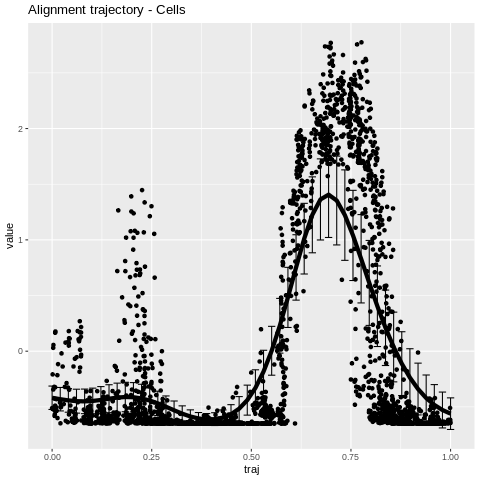

In [176]:
%%R

#plot of an example gene and its interpolation with error bars
ggplot(dfCelli, aes(x=traj,y=value)) +  
    geom_errorbar(aes(ymin=value-error/2, ymax=value+error/2)) + 
    geom_line(size = 2) + 
    geom_point(data=dfCellM, aes(x=traj,y=value)) + 
    ggtitle("Alignment trajectory - Cells") 

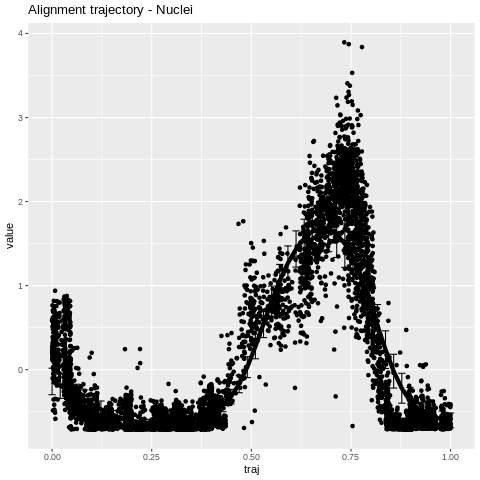

In [177]:
%%R

#plot of an example gene and its interpolation with error bars
ggplot(dfNuci, aes(x=traj,y=value)) +  
    geom_errorbar(aes(ymin=value-error/2, ymax=value+error/2)) + 
    geom_line(size = 2) + 
    geom_point(data=dfNucM, aes(x=traj,y=value)) + 
    ggtitle("Alignment trajectory - Nuclei") 

- plot the distances between bins of pseudotimes

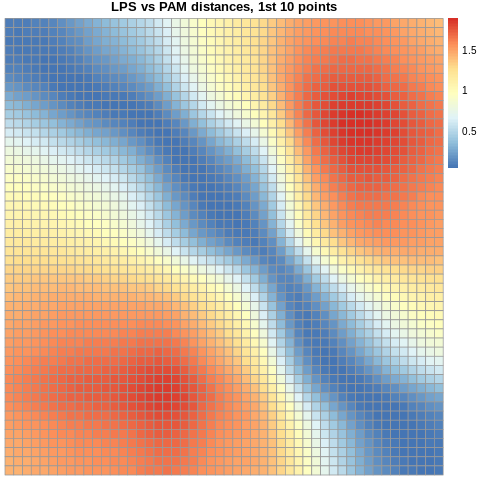

In [178]:
%%R
A=calcDistMat(nucData$interpolatedVals,cellData$interpolatedVals, dist.method = 'Cosine')
pheatmap(A, cluster_cols = F, cluster_rows=F, main = "LPS vs PAM distances, 1st 10 points",
          show_rownames = T, show_colnames = T,display_numbers = F)

R[write to console]: calculate dissimilarity matrix

R[write to console]: calculate cost and step matrices

R[write to console]: backtracking



[1] NA


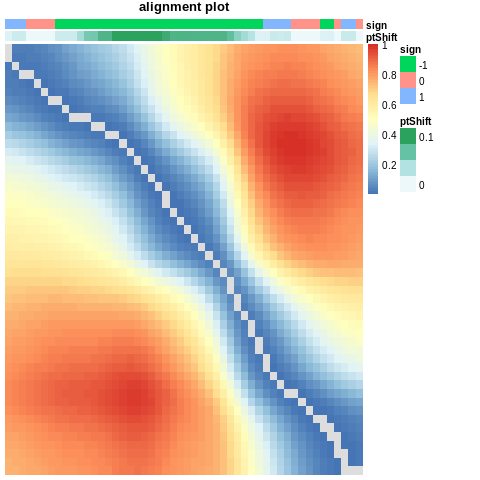

In [179]:
%%R

alignment = globalAlign(nucData$interpolatedVals, cellData$interpolatedVals,
                                   scores = list(query = nucData$traj, 
                                                 ref = cellData$traj),
                                   sigCalc = F, numPerm = 20, dist.method = "Cosine")
plotAlign(alignment)

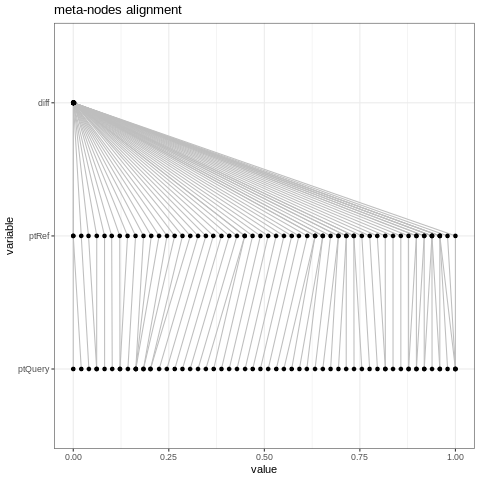

In [180]:
%%R

mapping = mapRealDataGlobal(alignment,intTrajQuery = nucData$traj, realTrajQuery = nucT,
                            intTrajRef = cellData$traj, realTrajRef = cellT)
plotMapping(mapping)

In [181]:
%%R -o mapping
ls(mapping)

[1] "metaNodesPt" "queryAssign" "refAssign"  


In [182]:
mapping['metaNodesPt']['diff']

1     0.000000
2     0.000589
3     0.000429
4     0.000892
5     0.000246
        ...   
59    0.000009
60    0.000048
61    0.000014
62    0.000234
63    0.000000
Name: diff, Length: 63, dtype: float64

In [183]:
cellDF = pd.DataFrame(np.array(mapping['metaNodesPt']['ptRef']), 
                      index=mapping['metaNodesPt']['metaNodeRef']  )

In [184]:
nucDF = pd.DataFrame(np.array(mapping['metaNodesPt']['ptQuery']), 
                      index=mapping['metaNodesPt']['metaNodeQuery']  )

In [185]:
nucNodes = pd.Series(index=nucNames)
cellNodes = pd.Series(index=cellNames)
for n,c,Tn,Tc in zip(nucDF.index, cellDF.index, nucDF[0], cellDF[0]):
    nucNodes[ mapping['queryAssign'][n] ] = Tn
    cellNodes[ mapping['refAssign'][c] ] = Tc

In [186]:
nucNodes

AAACCCAAGGACAGCT-Nuclei    0.897946
AAACCCACAGATCCTA-Nuclei    0.040901
AAACCCAGTTAGTCGT-Nuclei    0.265628
AAACGAAAGAGCATAT-Nuclei    0.428407
AAACGAAAGCTATCCA-Nuclei    0.285712
                             ...   
TTTGTTGCACTGCGAC-Nuclei    0.959206
TTTGTTGGTCCAGCAC-Nuclei    0.531297
TTTGTTGGTCCGTACG-Nuclei    0.693874
TTTGTTGTCGTACACA-Nuclei    0.265628
TTTGTTGTCTGGCCGA-Nuclei    0.142934
Length: 7174, dtype: float64

How to check Nan in the alignment and correction with the nearest neighbour (not a problem in this case)

In [187]:
idxNan = nucNodes.index[ np.where(np.isnan(nucNodes)) ]

In [188]:
idxNan

Index([], dtype='object')

In [189]:
idxNan = cellNodes.index[ np.where(np.isnan(cellNodes)) ]

In [190]:
idxNan

Index([], dtype='object')

correction:

In [191]:
#dist = pd.DataFrame( NUCLEI.uns['neighbors']['distances'].todense(), 
#                    index=adata_flt[adata_flt.obs['condition']=='nuclei'].obs_names,
#                    columns=adata_flt[adata_flt.obs['condition']=='nuclei'].obs_names )


In [192]:
#for i in idxNan:
#    gzero = dist.loc[i,:][ dist.loc[i,:]>0 ]
#    nucNodes.loc[ i ] = nucNodes.loc[ np.argmin(gzero) ]

Copying all the binned aligned pseudotimes in the original data object

In [193]:
concatTime = pd.concat([nucNodes, cellNodes])

In [194]:
dpt_cellalign_new = pd.Series(index=adata.obs_names)
dpt_cellalign_new[adata_flt.obs_names] = concatTime

In [195]:
dpt_cellalign_new[ [i not in adata_flt.obs_names for i in dpt_cellalign_new.index] ] = -1

In [196]:
adata.obs['dpt_palantir_magic_cellalign'] = dpt_cellalign_new.copy()

Some fancy plots

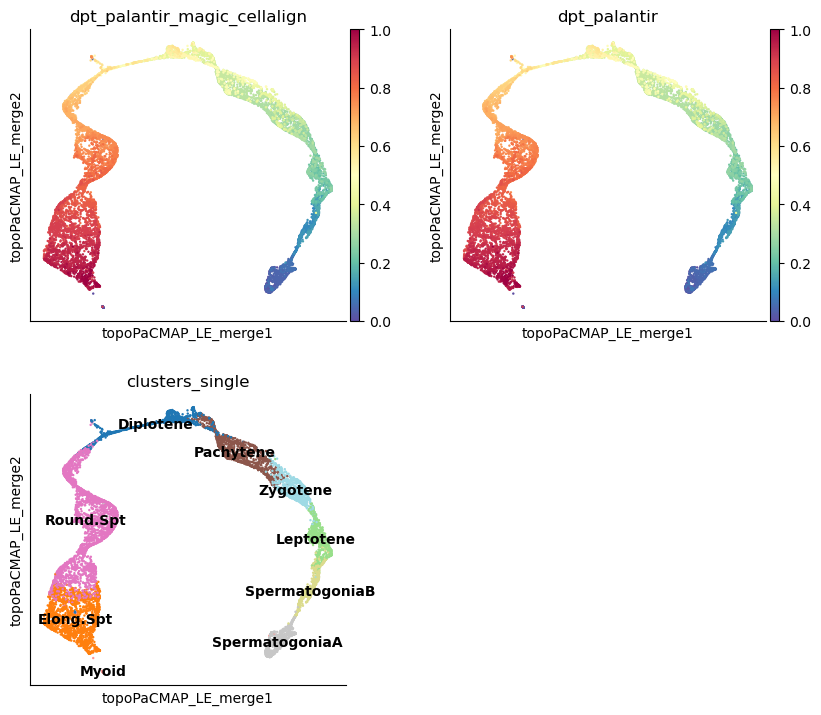

In [197]:
plt.rcParams["figure.figsize"] = (4, 4)
sc.pl.embedding(
    adata,
    basis="topoPaCMAP_LE_merge",
    color=['dpt_palantir_magic_cellalign', 'dpt_palantir', 'clusters_single'],
    palette="tab20",
    ncols=2,
    legend_loc="on data",
    legend_fontsize=10,
    vmin=0
)

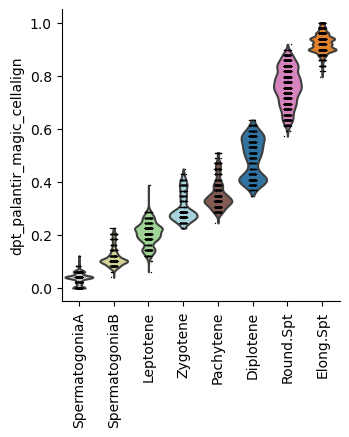

In [198]:
sc.pl.violin(adata, keys='dpt_palantir_magic_cellalign', groupby='clusters_single',
             order=['SpermatogoniaA','SpermatogoniaB','Leptotene','Zygotene',
                   'Pachytene','Diplotene','Round.Spt',
                   'Elong.Spt'], rotation=90)

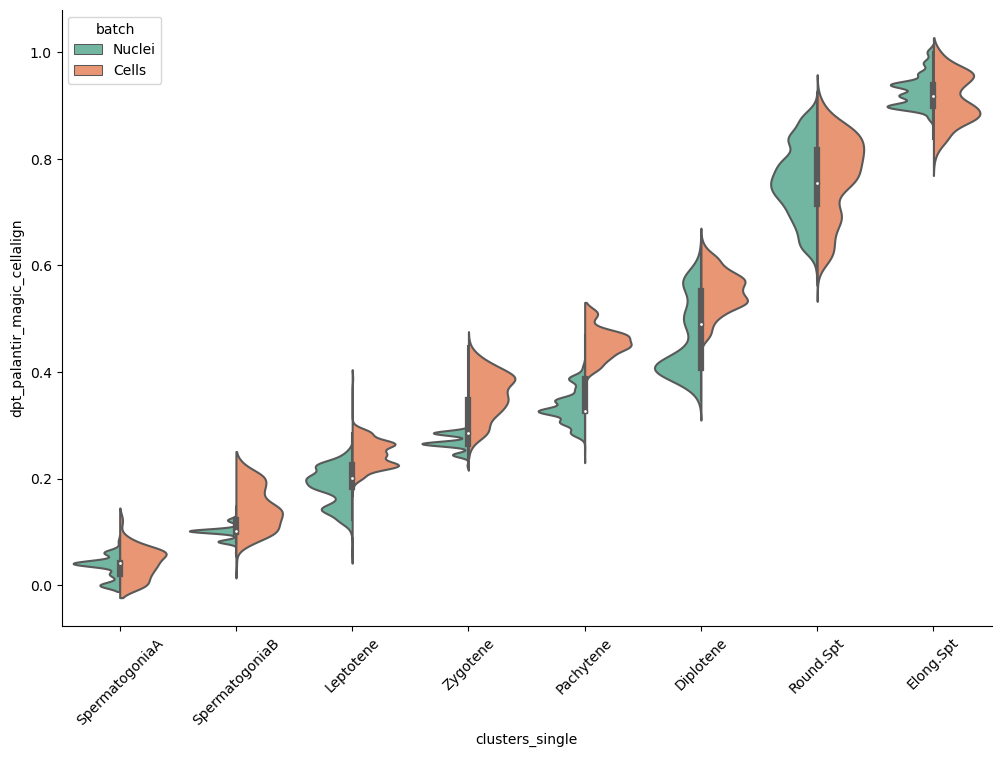

In [199]:
fig, (ax1) = plt.subplots(1, 1, figsize=(12,8), gridspec_kw={'wspace':0.5})
ax = sns.violinplot(x="clusters_single", y="dpt_palantir_magic_cellalign", hue="batch", 
                    scale="width", palette="Set2", split=True, ax=ax1,                    
                    data=adata.obs[ ['batch', 'dpt_palantir_magic_cellalign', 'clusters_single'] ], 
                    order=['SpermatogoniaA','SpermatogoniaB','Leptotene','Zygotene',
                   'Pachytene','Diplotene','Round.Spt',
                   'Elong.Spt'])
ax.tick_params(axis='x', rotation=45)

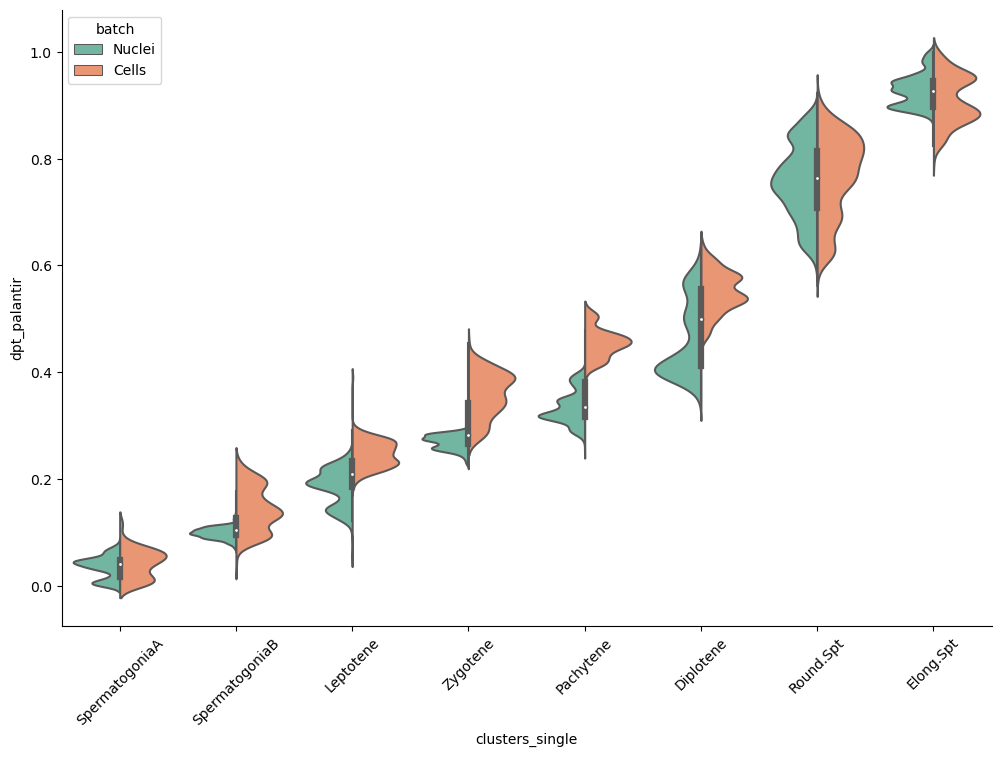

In [200]:
fig, (ax1) = plt.subplots(1, 1, figsize=(12,8), gridspec_kw={'wspace':0.5})
ax = sns.violinplot(x="clusters_single", y="dpt_palantir", hue="batch", 
                    scale="width", palette="Set2", split=True, ax=ax1,                    
                    data=adata.obs[ ['batch', 'dpt_palantir', 'clusters_single'] ], 
                    order=['SpermatogoniaA','SpermatogoniaB','Leptotene','Zygotene',
                   'Pachytene','Diplotene','Round.Spt',
                   'Elong.Spt'])
ax.tick_params(axis='x', rotation=45)

In [201]:
adata.write('./write/adata.dpt.magic.h5ad')

We also look at size of differences between pseudotimes to see the size of the correction

In [202]:
adata = sc.read('./write/adata.dpt.magic.h5ad')

Only considering the two last: ['.magic', '.h5ad'].
Only considering the two last: ['.magic', '.h5ad'].


In [203]:
nucDF = pd.DataFrame(np.array(mapping['metaNodesPt']['diff']), 
                      index=mapping['metaNodesPt']['metaNodeQuery']  )

In [204]:
nucNodes = pd.Series(index=nucNames)
for n,Tn in zip(nucDF.index, nucDF[0]):
    nucNodes[ mapping['queryAssign'][n] ] = Tn

In [205]:
nucNodes

AAACCCAAGGACAGCT-Nuclei    0.000046
AAACCCACAGATCCTA-Nuclei    0.000429
AAACCCAGTTAGTCGT-Nuclei    0.001182
AAACGAAAGAGCATAT-Nuclei    0.000018
AAACGAAAGCTATCCA-Nuclei    0.000050
                             ...   
TTTGTTGCACTGCGAC-Nuclei    0.000009
TTTGTTGGTCCAGCAC-Nuclei    0.000649
TTTGTTGGTCCGTACG-Nuclei    0.000208
TTTGTTGTCGTACACA-Nuclei    0.001182
TTTGTTGTCTGGCCGA-Nuclei    0.000314
Length: 7174, dtype: float64

In [206]:
NUCLEI.obs['dpt_diff'] = [nucNodes[i] if i in nucNodes.index 
                          else -1
                          for i in NUCLEI.obs_names]

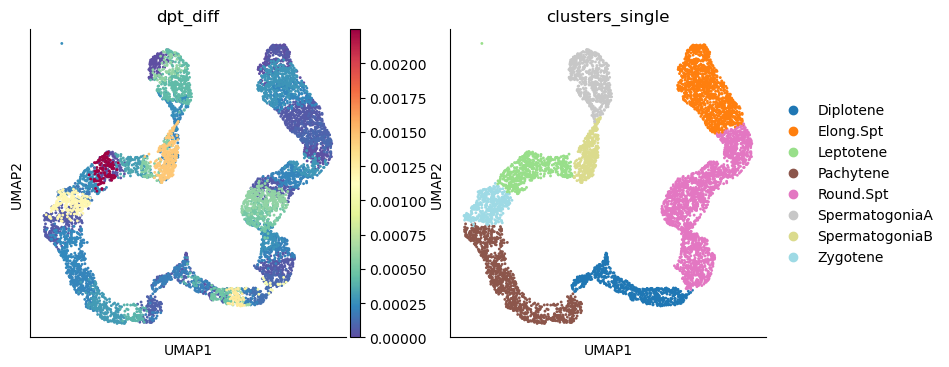

In [207]:
sc.pl.umap(NUCLEI, color=['dpt_diff','clusters_single'], vmin=0)

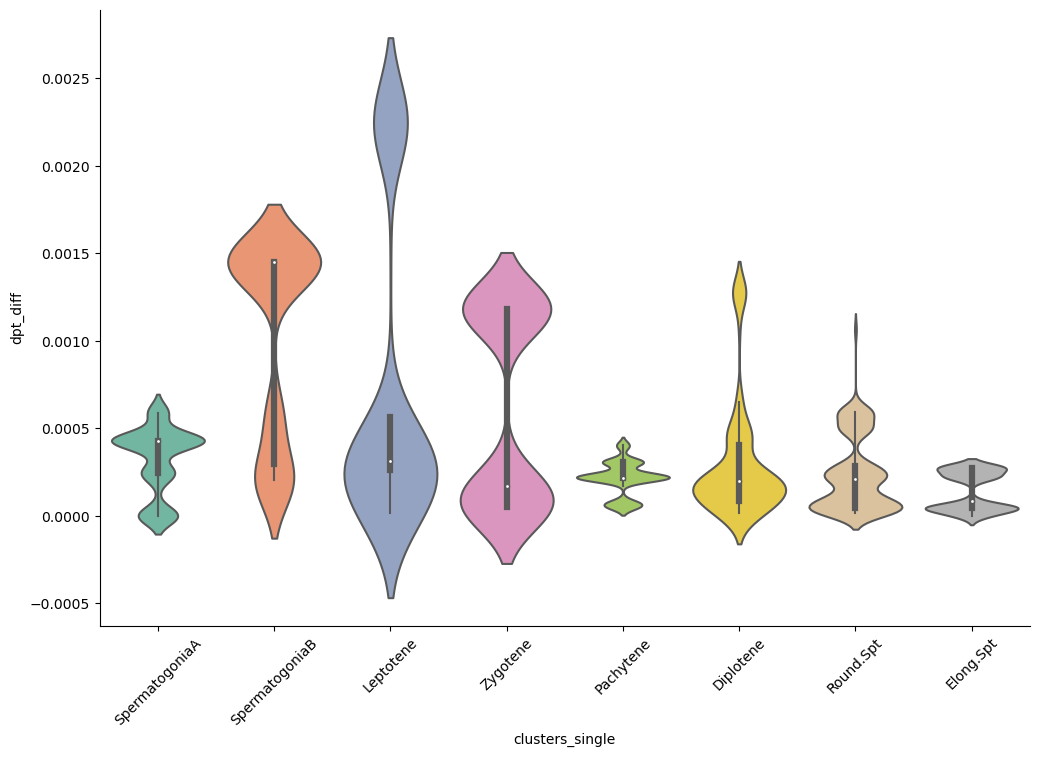

In [208]:
fig, (ax1) = plt.subplots(1, 1, figsize=(12,8), gridspec_kw={'wspace':0.5})
ax = sns.violinplot(x="clusters_single", y="dpt_diff", 
                    scale="width", palette="Set2", ax=ax1,                    
                    data=NUCLEI.obs[ ['dpt_diff', 'clusters_single'] ], 
                    order=['SpermatogoniaA','SpermatogoniaB','Leptotene','Zygotene',
                   'Pachytene','Diplotene','Round.Spt',
                   'Elong.Spt'])
ax.tick_params(axis='x', rotation=45)

Almost no difference when using imputation and aligning pseudotimes when comparing with the alignment approach without imputed gene expressions, but most difference is in cell types instead of in the pairs query-reference